In [1]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


# Check to see if we're running in Colab (versus local server)

In [2]:
try:
  from google.colab import drive
  IN_COLAB=True
except:
  IN_COLAB=False

if IN_COLAB:
  print("We're running Colab")

We're running Colab


# Tensorflow with GPU

This notebook provides an introduction to computing on a [GPU](https://cloud.google.com/gpu) in Colab. In this notebook you will connect to a GPU, and then run some basic TensorFlow operations on both the CPU and a GPU, observing the speedup provided by using the GPU.


## Enabling and testing the GPU

First, you'll need to enable GPUs for the notebook:

- Navigate to Edit→Notebook Settings
- select GPU from the Hardware Accelerator drop-down

Next, we'll confirm that we can connect to the GPU with tensorflow:

In [3]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


## Observe TensorFlow speedup on GPU relative to CPU

This example constructs a typical convolutional neural network layer over a
random image and manually places the resulting ops on either the CPU or the GPU
to compare execution speed.

In [4]:
import tensorflow as tf
import timeit

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print(
      '\n\nThis error most likely means that this notebook is not '
      'configured to use a GPU.  Change this in Notebook Settings via the '
      'command palette (cmd/ctrl-shift-P) or the Edit menu.\n\n')
  raise SystemError('GPU device not found')

def cpu():
  with tf.device('/cpu:0'):
    random_image_cpu = tf.random.normal((100, 100, 100, 3))
    net_cpu = tf.keras.layers.Conv2D(32, 7)(random_image_cpu)
    return tf.math.reduce_sum(net_cpu)

def gpu():
  with tf.device('/device:GPU:0'):
    random_image_gpu = tf.random.normal((100, 100, 100, 3))
    net_gpu = tf.keras.layers.Conv2D(32, 7)(random_image_gpu)
    return tf.math.reduce_sum(net_gpu)

# We run each op once to warm up; see: https://stackoverflow.com/a/45067900
cpu()
gpu()

# Run the op several times.
print('Time (s) to convolve 32x7x7x3 filter over random 100x100x100x3 images '
      '(batch x height x width x channel). Sum of ten runs.')
print('CPU (s):')
cpu_time = timeit.timeit('cpu()', number=10, setup="from __main__ import cpu")
print(cpu_time)
print('GPU (s):')
gpu_time = timeit.timeit('gpu()', number=10, setup="from __main__ import gpu")
print(gpu_time)
print('GPU speedup over CPU: {}x'.format(int(cpu_time/gpu_time)))

Time (s) to convolve 32x7x7x3 filter over random 100x100x100x3 images (batch x height x width x channel). Sum of ten runs.
CPU (s):
0.33735167800000454
GPU (s):
0.07279498499997317
GPU speedup over CPU: 4x


# Start of the code

In [6]:
# import csv
# if os.path.exists('./exp/'+ result_dir+'/result.csv') == True:

#     # [Hyosun] load acc (ind=0 at result.csv)
#     results_mlp2_mean = np.loadtxt('./exp/'+ result_dir+'/result.csv', delimiter=',', dtype='str')
#     results_mlp2_mean = np.array(results_mlp2_mean, dtype=float)
#     print("results_mlp2_mean[:,0]: \n", results_mlp2_mean[:,0])
#     print("results_mlp2_mean[:,0].size: ", results_mlp2_mean[:,0].size)
#     print("results_mlp2_mean[:,2]: \n", results_mlp2_mean[:,2])
#     print("results_mlp2_mean[:,2].size: ", results_mlp2_mean[:,2].size)
#     print("results_mlp2_mean[:,3]: \n", results_mlp2_mean[:,3])
#     print("results_mlp2_mean[:,3].size: ", results_mlp2_mean[:,3].size)
#     print("results_mlp2_mean.shape: ", results_mlp2_mean.shape)

In [44]:
import os
current_file = 'logs_2022-12-09.txt'
current_file_name, ext =current_file.split('.')
# Open and extract the lines of the data file
with open(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/', 'logs_2022-12-09.txt'), 'r') as f:
    lines = f.readlines()
f.close()

epoch_list, train_acc_list, test_acc_list, avg_loss_batch_list = [], [], [], []
# loop through lines of the file
for line in lines:
    # remove newline and extract data from line
    e, epoch, tr, tra, train_acc, te, tea, test_acc, avg, loss_batch, avg_loss_batch = line.strip().split(' ')
    epoch_list.append(int(epoch))
    train_acc_list.append(float(train_acc))
    test_acc_list.append(float(test_acc))
    avg_loss_batch_list.append(float(avg_loss_batch))
    print("epoch: %s, train_acc: %s, test_acc: %s, avg_loss_batch: %s" % (epoch, train_acc, test_acc, avg_loss_batch))
    # print

epoch: 0, train_acc: 0.424505, test_acc: 0.580374, avg_loss_batch: 1.610931
epoch: 1, train_acc: 0.656306, test_acc: 0.726995, avg_loss_batch: 0.977689
epoch: 2, train_acc: 0.760347, test_acc: 0.773960, avg_loss_batch: 0.718491
epoch: 3, train_acc: 0.806969, test_acc: 0.765941, avg_loss_batch: 0.576875
epoch: 4, train_acc: 0.847211, test_acc: 0.820924, avg_loss_batch: 0.445828
epoch: 5, train_acc: 0.874530, test_acc: 0.823597, avg_loss_batch: 0.366720
epoch: 6, train_acc: 0.902994, test_acc: 0.840015, avg_loss_batch: 0.288222
epoch: 7, train_acc: 0.917389, test_acc: 0.814433, avg_loss_batch: 0.237680
epoch: 8, train_acc: 0.939310, test_acc: 0.840397, avg_loss_batch: 0.187205
epoch: 9, train_acc: 0.945526, test_acc: 0.822833, avg_loss_batch: 0.166321
epoch: 10, train_acc: 0.955177, test_acc: 0.850706, avg_loss_batch: 0.134788
epoch: 11, train_acc: 0.959921, test_acc: 0.852997, avg_loss_batch: 0.122740
epoch: 12, train_acc: 0.967119, test_acc: 0.844597, avg_loss_batch: 0.094390
epoch: 13

In [45]:
print(train_acc_list)

[0.424505, 0.656306, 0.760347, 0.806969, 0.847211, 0.87453, 0.902994, 0.917389, 0.93931, 0.945526, 0.955177, 0.959921, 0.967119, 0.966792, 0.971209, 0.978407, 0.973826, 0.977589, 0.978734, 0.98037, 0.977098, 0.984623, 0.981678, 0.987404, 0.975462, 0.98904, 0.987404, 0.978407, 0.987077, 0.983805, 0.989203, 0.990348, 0.988549, 0.996565, 0.974808, 0.990348, 0.985604, 0.995256, 0.985441, 0.990676, 0.989694, 0.98724, 0.986586, 0.993947, 0.994602, 0.989367, 0.991003, 0.991821, 0.99362, 0.999018]


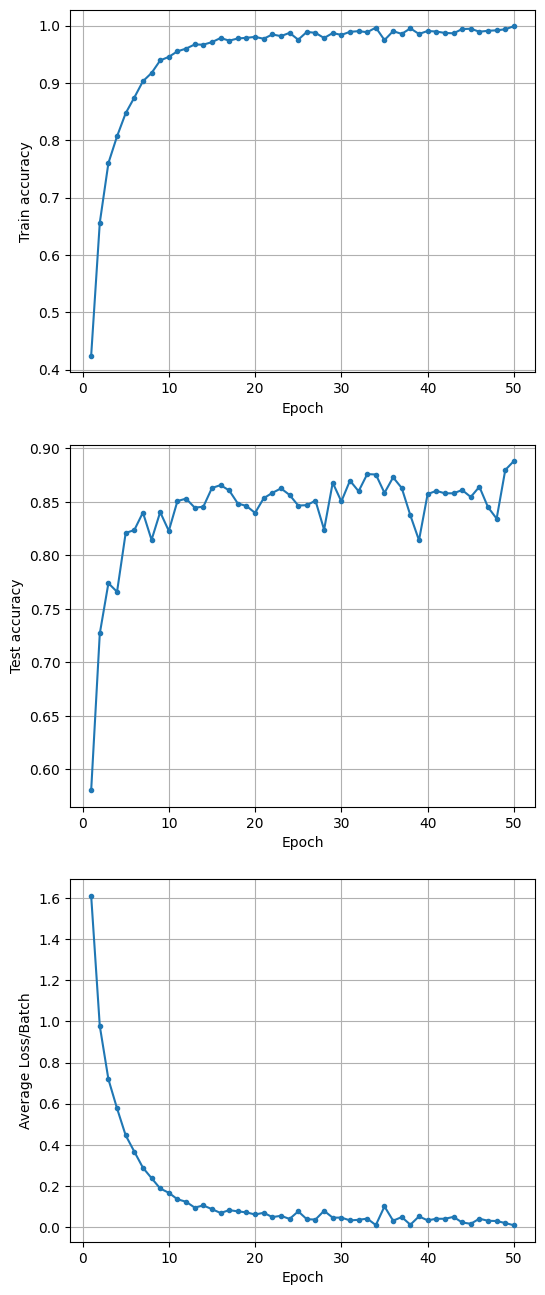

In [50]:
import matplotlib.pyplot as plt
import numpy as np
fig, axs = plt.subplots(3,1,figsize=(6, 16))
# fig.suptitle('[Emotions] Average Precision with various number of layers at mlp_head') #, fontdict={'fontsize': 10}, loc='center', )


#mlp_head with 2 layers
axs[0].plot([i for i in range(1, np.size(epoch_list)+1)],        train_acc_list, 'o-', markersize=3, label='train accuracy')
# axs[0].plot([i for i in range(1, results_mlp2_mean[:,2].size+1)],    results_mlp2_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# axs[0].plot([i for i in range(1, results_mlp2_meanmax[:,2].size+1)], results_mlp2_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# axs[0].plot([i for i in range(1, results_mlp2_max[:,2].size+1)],     results_mlp2_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# axs[0].plot([i for i in range(1, results_mlp2_maxmax[:,2].size+1)],  results_mlp2_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# axs[0].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# plt.xticks(rotation=45)
# axs[0].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# axs[0].set_yticks(np.arange(0, np.max(results_mlp2_maxmax[:,0])+0.05, 0.001)) #, rotation=45)
# axs[0].set_ylim(0.216, 0.234)
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Train accuracy')
axs[0].grid(True, linestyle='-')
# axs[0].set_title('Train accuracy', fontdict={'fontsize': 10}, loc='center', )
# fig.savefig('[IurbanEvent]Accuracy_num-layers_mlphead.png',dpi=300)

#mlp_head with 4 layers
axs[1].plot([i for i in range(1, np.size(epoch_list)+1)],        test_acc_list, 'o-', markersize=3, label='test accuracy')
# axs[1].plot([i for i in range(1, results_mlp4_mean[:,2].size+1)],    results_mlp4_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# axs[1].plot([i for i in range(1, results_mlp4_meanmax[:,2].size+1)], results_mlp4_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# axs[1].plot([i for i in range(1, results_mlp4_max[:,2].size+1)],     results_mlp4_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# axs[1].plot([i for i in range(1, results_mlp4_maxmax[:,2].size+1)],  results_mlp4_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# axs[1].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# plt.xticks(rotation=45)
# axs[1].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# axs[1].set_yticks(np.arange(0, np.max(results_mlp4_maxmax[:,2])+0.05, 0.001)) #, rotation=45)
# axs[1].set_ylim(0.212, 0.234)
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Test accuracy')
axs[1].grid(True, linestyle='-')
# axs[1].set_title('Test accuracy', fontdict={'fontsize': 10}, loc='center', )
# fig.savefig('[IurbanEvent]Accuracy_num-layers_mlphead.png',dpi=300)

#mlp_head with 6 layers
axs[2].plot([i for i in range(1, np.size(epoch_list)+1)],        avg_loss_batch_list, 'o-', markersize=3, label='average loss/batch')
# axs[2].plot([i for i in range(1, results_mlp6_mean[:,2].size+1)],    results_mlp6_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# axs[2].plot([i for i in range(1, results_mlp6_meanmax[:,2].size+1)], results_mlp6_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# axs[2].plot([i for i in range(1, results_mlp6_max[:,2].size+1)],     results_mlp6_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# axs[2].plot([i for i in range(1, results_mlp6_maxmax[:,2].size+1)],  results_mlp6_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# axs[2].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# plt.xticks(rotation=45)
# axs[2].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# axs[2].set_yticks(np.arange(0, np.max(results_mlp6_maxmax[:,2])+0.05, 0.001)) #, rotation=45)
# axs[2].set_ylim(0.216, 0.234)
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Average Loss/Batch')
axs[2].grid(True, linestyle='-')
# axs[2].set_title('Average Loss/Batch', fontdict={'fontsize': 10}, loc='center', )


fig.savefig('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/'+current_file_name+ 'VGG19_transfer_train_test_acc_loss.png',dpi=300)

In [48]:
!ls

sample_data  VGG19_transfer_train_test_acc_loss.png


In [49]:
os.getcwd()

'/content'